# **Physics-Informed Neural Networks (PINNs) for Chemical Kinetics**

This notebook demonstrates how to solve a first-order irreversible reaction differential equation using two different frameworks:
1. **DeepXDE**: A library specifically designed for scientific machine learning.
2. **PyTorch**: A general-purpose deep learning framework, implemented from scratch.

In this notebook, we will solve the first order reaction of an irreversible reaction of a species inside a batch reactor.

**Problem Statement**:
Consider an irreversible first order reaction of a species $A$ taking place in a batch reactor isothermally. We are known with the rate constant $k$ and the initial concentration of the reactant $C_0$ . We need to solve the governing differntial equation by training the neural network and see the decay of the reactant concentration with respect to time $t$.

The reaction:
$$A→R$$

The governing differential equation of this reaction is given by

$$\frac{dC}{dt} = -k C, \qquad t \in [0, 10]$$

with the parameters

1. Rate constant $k = 0.3 s^{-1}$
2. Initial Concentration $C_0 = 1 mol/L$

The analytical solution is given by $C(t) = C_0 e^{-kt}$

## 1. DeepXDE Implementation
We start by defining the geometry (time domain), the PDE residual, and the initial conditions using the high-level DeepXDE API.

In [ ]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
# import libraries
import deepxde as dde
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [ ]:
# Defining the parameters
k = 0.3  # Rate constant - Units: s^-1
c0 = 1   # Initial Concentration of A - Units: mol/L

In [ ]:
# Defining the computational domain
timedomain = dde.geometry.TimeDomain(0, 10)  # The time was considered to be 0 to 10

In [ ]:
# Defining the governing differential equation
def pde(t, c):
  dc_dt = dde.grad.jacobian(c, t, i=0)
  return dc_dt + k*c

In [ ]:
# defining the exact solution
def exact(t):
  return c0*tf.exp(-k*t)

In [ ]:
# Defining the initial condition
def on_initial(t, on_boundary):
  return on_boundary and dde.utils.isclose(t[0], 0)
ic = dde.icbc.IC(timedomain, lambda t: c0, on_initial)

In [ ]:
# defining the problem
data = dde.data.PDE(timedomain, pde, ic, num_domain=100, num_boundary=1, solution=exact, num_test=150)

In [ ]:
# defining the neural network
layer_size = [1] + [15] * 2 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

In [ ]:
# Initialize the model and run it
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=5000)

Compiling model...
'compile' took 0.015415 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x794cadcad620>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x794cadcad620>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric   
0         [3.47e-02, 1.00e+00]    [3.07e-02, 1.00e+00]    [5.96e-01]    
1000      [2.82e-04, 1.09e-07]    [1.97e-04, 1.09e-07]    [1.68e-02]    
2000      [1.47e-04, 3.08e-08]    [1.02e-04, 3.08e-08]    [1.18e-02]    
3000      [6.50e-05, 5.80e-09]    [4.54e-05, 5.80e-09]    [7.89e-03]    
4000      [2.89e-05, 1.16e-09]    [1.91e-05, 1.16e-09]    [4.92e-03]    
5000      [1.30e-05, 9.09e-13]    [7.89e-06, 9.09e-13]    [2.75e-03]    

Best

### Visualization of DeepXDE Results
Below we compare the PINN prediction against the analytical solution $C(t) = C_0 e^{-kt}$.

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


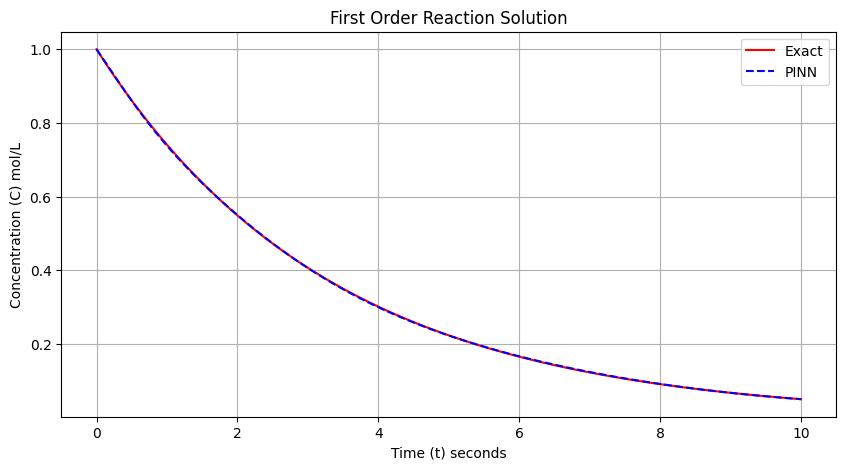

In [ ]:
# Manual plotting to avoid the internal DeepXDE TypeError with TensorFlow tensors
import matplotlib.pyplot as plt

# Plot loss history
dde.saveplot(losshistory, train_state, issave=True, isplot=False)

# Custom plot for results
t = np.linspace(0, 10, 100).reshape(-1, 1)
c_pred = model.predict(t)
c_true = c0 * np.exp(-k * t)

plt.figure(figsize=(10, 5))
plt.plot(t, c_true, 'r-', label='Exact')
plt.plot(t, c_pred, 'b--', label='PINN')
plt.xlabel('Time (t) seconds')
plt.ylabel('Concentration (C) mol/L')
plt.title('First Order Reaction Solution')
plt.legend()
plt.grid(True)
plt.show()

## 2. PyTorch Implementation
In this section, we implement the PINN manually. This involves defining the neural network architecture, the automatic differentiation for the PDE residual, and the custom loss function.

In [ ]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Defining the parameters
k = 0.3  # Rate constant - Units: s^-1
c0 = 1   # Initial Concentration of A - Units: mol/L

In [ ]:
# Defining the neural network
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(1, 15)
    self.fc2 = nn.Linear(15, 15)
    self.fc3 = nn.Linear(15, 1)

  def forward(self, x):
    a1 = torch.tanh(self.fc1(x))
    a2 = torch.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output
net = Net()
print(net)

Net(
  (fc1): Linear(in_features=1, out_features=15, bias=True)
  (fc2): Linear(in_features=15, out_features=15, bias=True)
  (fc3): Linear(in_features=15, out_features=1, bias=True)
)


In [ ]:
# Defining the pde
def pde(net, t):
  C = net(t)

  # Defining the derivatives
  # grad returns a tuple, so we take the first element [0]
  dC_dt = torch.autograd.grad(C, t, torch.ones_like(C), create_graph=True)[0]

  # Defining the governing equation
  pde_res = dC_dt + k*C
  return pde_res

In [ ]:
# Defining the overall loss
def compute_loss(net, t, t_ic, C_ic):
  # Defining the type of loss
  mse_loss = nn.MSELoss()

  # PDE loss
  pde_res = pde(net, t)
  pde_loss = mse_loss(pde_res, torch.zeros_like(pde_res))

  # IC loss
  ic_res = net(t_ic) - C_ic
  ic_loss = mse_loss(ic_res, torch.zeros_like(ic_res))

  # compute total loss
  total_loss = pde_loss + ic_loss
  return total_loss, pde_loss, ic_loss

In [ ]:
# Defining the collocation points to train the neural network
t = torch.linspace(0, 10, 100).reshape(-1, 1).requires_grad_(True)
t_ic = torch.tensor([[0.0]], requires_grad=True)
C_ic = torch.tensor([[float(c0)]])

In [ ]:
# Training the neural network
epochs = 5000
optimizer = optim.Adam(net.parameters(), lr=0.001)

# storing the losses
losses = []
pde_losses = []
ic_losses = []

for epoch in range(epochs+1):
  optimizer.zero_grad()
  total_loss, pde_loss, ic_loss = compute_loss(net, t, t_ic, C_ic)
  total_loss.backward()
  optimizer.step()
  losses.append(total_loss.item())
  pde_losses.append(pde_loss.item())
  ic_losses.append(ic_loss.item())
  if epoch % 1000 == 0:
    print(f'Epoch {epoch}: Loss {total_loss.item():.4e}')

Epoch 0: Loss 1.6224e+00
Epoch 1000: Loss 2.5851e-04
Epoch 2000: Loss 9.4765e-05
Epoch 3000: Loss 4.7593e-05
Epoch 4000: Loss 2.8143e-05
Epoch 5000: Loss 1.7414e-05


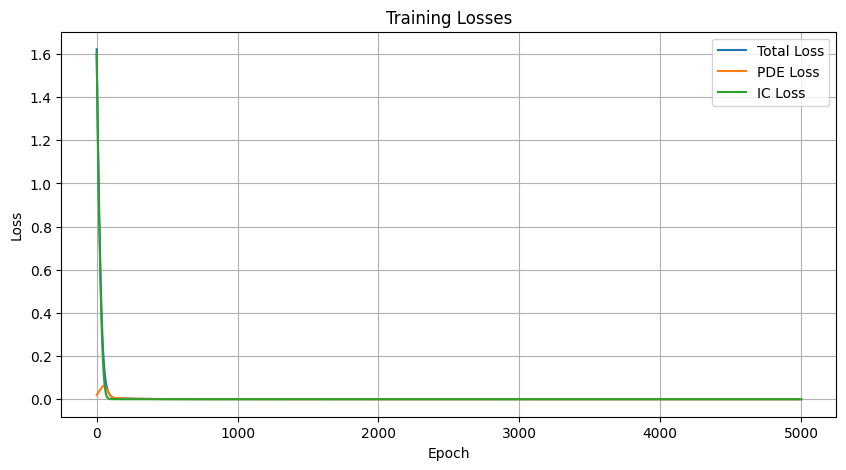

In [ ]:
# Plotting the losses
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Total Loss')
plt.plot(pde_losses, label='PDE Loss')
plt.plot(ic_losses, label='IC Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)
plt.show()

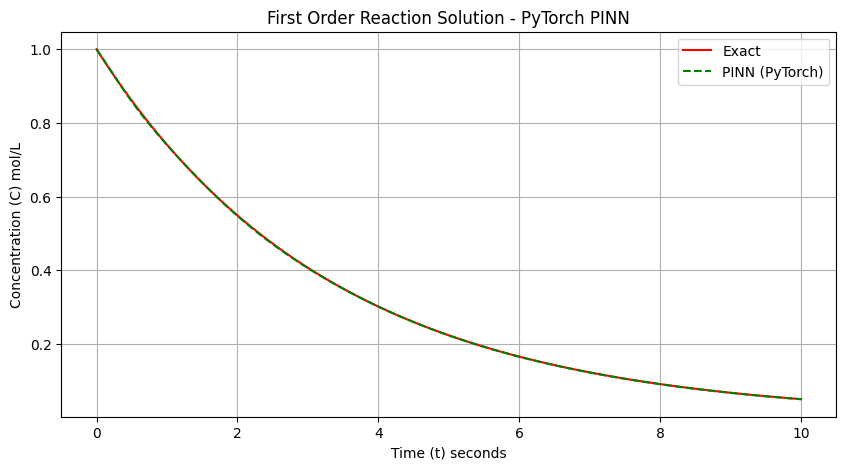

In [ ]:
# Custom plot for PyTorch results
with torch.no_grad():
    t_plot = torch.linspace(0, 10, 100).reshape(-1, 1)
    c_pred_pytorch = net(t_plot).numpy()

t_eval = np.linspace(0, 10, 100).reshape(-1, 1)
c_true = c0 * np.exp(-k * t_eval)

plt.figure(figsize=(10, 5))
plt.plot(t_eval, c_true, 'r-', label='Exact')
plt.plot(t_eval, c_pred_pytorch, 'g--', label='PINN (PyTorch)')
plt.xlabel('Time (t) seconds')
plt.ylabel('Concentration (C) mol/L')
plt.title('First Order Reaction Solution - PyTorch PINN')
plt.legend()
plt.grid(True)
plt.show()

## Conclusion
Both DeepXDE and manual PyTorch implementations successfully captured the exponential decay of the reactant. PINNs offer a powerful way to integrate physical laws (ODEs/PDEs) directly into the neural network training process.